# Exploratory Data Analysis

In [1]:
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
import plotly.graph_objects as go
import torch

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.data.jet_constituents_data_loading import JetConstL1TriggerDataset

Let us start by viewing the features of a generic parquet data file.

In [3]:
file_path = "/run/media/francesco/STORAGE/data_cern/Train/HH_4b/HH_4b-NEVENT10000-RS20000001.parquet"

parquet_file = pq.read_schema(file_path)

In [4]:
parquet_file.names

['FullReco_PUPPIPart_PT',
 'FullReco_PUPPIPart_Eta',
 'FullReco_PUPPIPart_Phi',
 'FullReco_PUPPIPart_E',
 'FullReco_PUPPIPart_Charge',
 'FullReco_PUPPIPart_Mass',
 'FullReco_PUPPIPart_PID',
 'FullReco_PUPPIPart_D0',
 'FullReco_PUPPIPart_DZ',
 'FullReco_PUPPIPart_ErrorD0',
 'FullReco_PUPPIPart_ErrorDZ',
 'FullReco_PUPPIPart_fUniqueID',
 'FullReco_PUPPIPart_PuppiW',
 'FullReco_PUPPIPart_IsPU',
 'FullReco_PUPPIPart_IsRecoPU',
 'FullReco_PFPart_PT',
 'FullReco_PFPart_Eta',
 'FullReco_PFPart_Phi',
 'FullReco_PFPart_E',
 'FullReco_PFPart_Charge',
 'FullReco_PFPart_Mass',
 'FullReco_PFPart_PID',
 'FullReco_PFPart_D0',
 'FullReco_PFPart_DZ',
 'FullReco_PFPart_ErrorD0',
 'FullReco_PFPart_ErrorDZ',
 'FullReco_PFPart_fUniqueID',
 'FullReco_PFPart_PuppiW',
 'FullReco_PFPart_IsPU',
 'FullReco_PFPart_IsRecoPU',
 'FullReco_Electron_PT',
 'FullReco_Electron_Eta',
 'FullReco_Electron_Phi',
 'FullReco_Electron_Charge',
 'FullReco_Electron_EhadOverEem',
 'FullReco_Electron_IsolationVar',
 'FullReco_Elect

In [5]:
print(f'Num_events:{len(df["L1T_PUPPIPart_PT"])}')
print(f'Num_elem_per_event:{len(df["L1T_PUPPIPart_PT"][0])}')

Num_events:8660
Num_elem_per_event:1000


We are interested in L1-trigger data, in particular on the kinematic features $p_T$, $\eta$ and $\phi$.

## Jet-constituents-level

In [ ]:
# Initialize train dataset
dataset = JetConstL1TriggerDataset(
    parquet_dirs="/run/media/francesco/STORAGE/data_cern/Val",
    max_particles=128,
    features=["L1T_PUPPIPart_PT",
            "L1T_PUPPIPart_Eta",
            "L1T_PUPPIPart_Phi",
            "L1T_PUPPIPart_PuppiW",
            "L1T_JetPuppiAK4_PT",
            "L1T_JetPuppiAK4_Eta",
            "L1T_JetPuppiAK4_Phi",
            "L1T_JetPuppiAK4_Mass",
            "L1T_JetPuppiAK4_ConstituentsIdx"
        ],
    preprocessing=False
)

# Initialize train dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    num_workers=0,
    pin_memory=True
)

In [35]:
pt = []
eta = []
phi = []
tot_jets = 0
num_const = []

for x, m, j in dataloader:
    pt.extend(x[:, :, 0][m])
    eta.extend(x[:, :, 1][m])
    phi.extend(x[:, :, 2][m])

    num_const.extend(m.sum(axis=1))

    tot_jets += x.shape[0]

In [36]:
print(f"Total jets: {tot_jets}")

Total jets: 123497


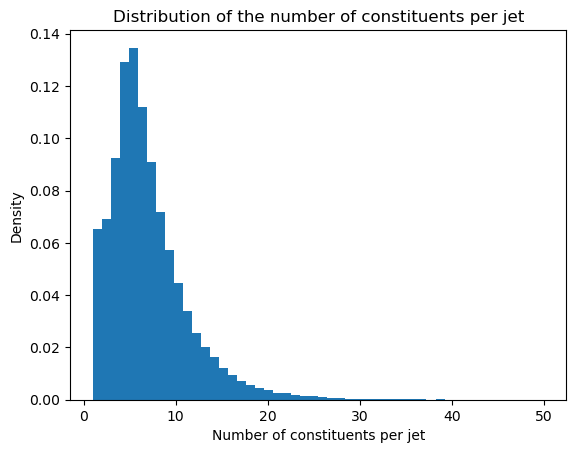

In [39]:
plt.hist(num_const, bins=50, density=True)
plt.xlabel("Number of constituents per jet")
plt.ylabel("Density")
plt.title("Distribution of the number of constituents per jet")
plt.show()

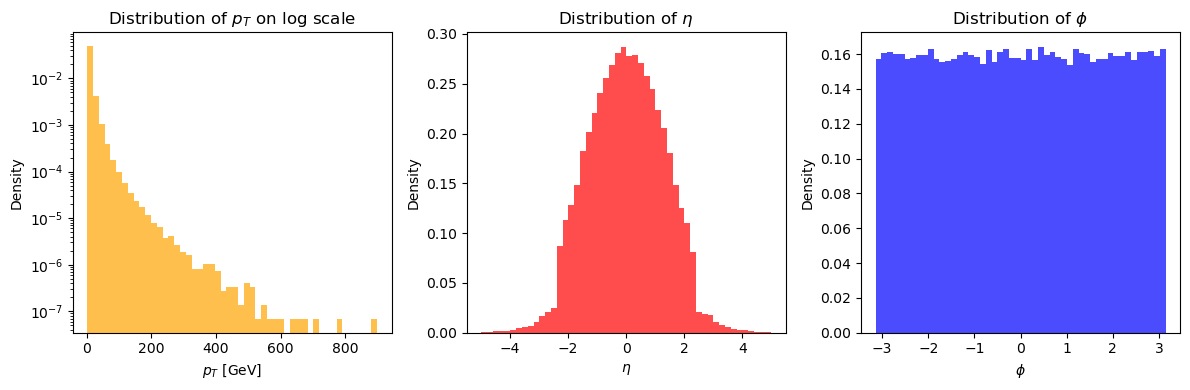

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(pt, bins=50, density=True, log=True, color = "orange", histtype='stepfilled', alpha=0.7)
ax[0].set_xlabel(r"$p_T$ [GeV]")
ax[0].set_ylabel("Density")
ax[0].set_title(r"Distribution of $p_T$ on log scale")

ax[1].hist(eta, bins=50, density=True, color = "red", histtype='stepfilled', alpha=0.7)
ax[1].set_xlabel(r"$\eta$")
ax[1].set_ylabel("Density")
ax[1].set_title(r"Distribution of $\eta$")

ax[2].hist(phi, bins=50, density=True, color = "blue", histtype='stepfilled', alpha=0.7)
ax[2].set_xlabel(r"$\phi$")
ax[2].set_ylabel("Density")
ax[2].set_title(r"Distribution of $\phi$")

plt.tight_layout()
plt.show()